# Practice EDA
Exploratory analysis across five dimensions:
1. **Practice Size, Growth & Demand**
2. **NHS vs Private Mix & Revenue**
3. **Standard vs Specialist Referral Intensity**
4. **Workforce Mix & Role Design**
5. **Capacity & Productivity (Whitespace)**

## How to use this notebook

Each section produces charts and tables at **portfolio level** and, where possible,
flags **practice-level signals** — the metrics that tell you how an individual practice
compares to its peers and where action may be warranted.

Look for practices that sit:
- **More than one standard deviation from the portfolio median** — worth investigating
- **In the bottom quartile on productivity but top quartile on size** — over-resourced relative to output
- **In the top quartile on income but bottom quartile on staffing** — potential burnout or capacity ceiling risk

> **Data note:** NHS income is taken directly from the `nhsincome` column.
> Referral patient columns (`noofpatients_private_referral`, `noofpatients_nhs_referral`)
> are populated in the synthetic data and drive specialist classification.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
PALETTE   = 'Set2'
BLUE      = '#4C72B0'
ORANGE    = '#DD8452'
GREEN     = '#55A868'
RED       = '#C44E52'
GREY      = '#8C8C8C'

sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('master.csv')

# Parse acquisition date
df['acquiredon'] = pd.to_datetime(df['acquiredon'], errors='coerce')
df['acquired_year'] = df['acquiredon'].dt.year

print(f'Loaded {len(df):,} practices | Columns: {df.shape[1]}')
df.head(3)

Loaded 400 practices | Columns: 53


,practicekey,practicecode,practicename,brandname,practiceid,region,campus,postcode,numberofsurgeries,numberofchairs,...,chargeprice_private_standard,chargeprice_private_referral,chargeprice_nhs_standard,chargeprice_nhs_referral,monthkey_y,privateincome,uda,latest_month_y,countof_snareid,acquired_year
0,PK_1000,7804,Bupa Dental North 0,Bupa Dental Care,ID-758,Midlands,Campus A,SW19 4AB,9,9,...,0,0,0,0,0,20626.92,3635,0,0,2024
1,PK_1001,6147,Bupa Dental West 1,Bupa Dental Care,ID-487,Scotland,Campus A,SW14 5AB,2,2,...,0,0,0,0,0,42815.14,3255,0,0,2025
2,PK_1002,7020,Bupa Dental Central 2,Bupa Dental Care,ID-550,North East,Main,SW4 7AB,7,7,...,0,0,0,0,0,17566.78,4107,0,0,2023


---
## 1 · Practice Size, Growth & Demand

### What this section tells us

Practice size is the baseline context for every other metric. A practice with 9 surgeries
and 500 treatment items is behaving very differently from one with 3 surgeries and 500
items — the latter is working hard, the former has significant whitespace.

**Key practice-level questions to ask here:**
- Is the practice's treatment volume in line with its physical capacity (surgeries)?
- Is there a large gap between `numberofchairs` and `numberofsurgeries`? Extra chairs suggest
  sessions are being run — or that chair capacity is unused.
- How does the practice's staff headcount compare to the portfolio median for its surgery count?
  Outliers (high staff / low surgeries, or vice versa) often signal staffing model misalignment.

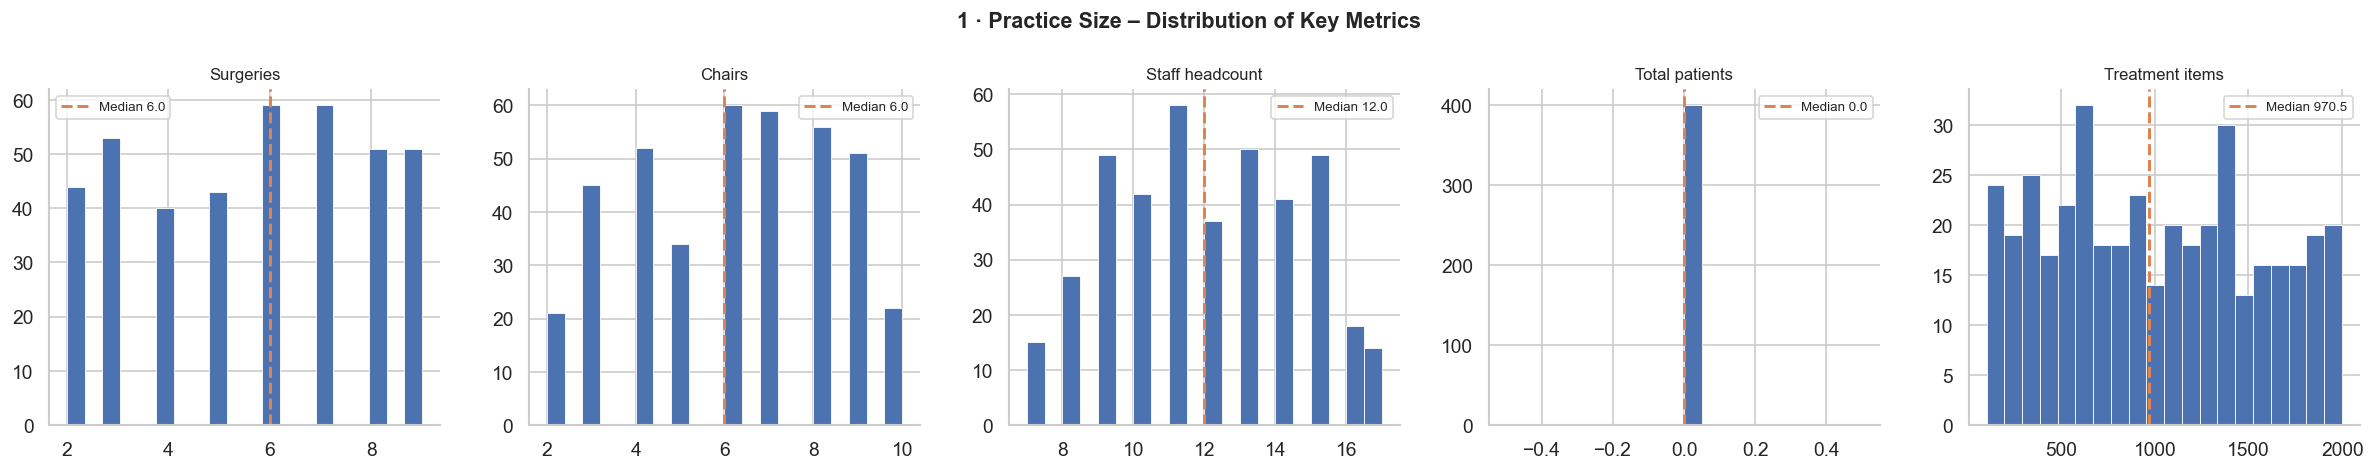

       numberofsurgeries  numberofchairs  unique_staff_ids  total_patients  total_treatment_items
count              400.0           400.0             400.0           400.0                  400.0
mean                 5.6             6.1              11.9             0.0                 1003.5
std                  2.3             2.3               2.6             0.0                  549.3
min                  2.0             2.0               7.0             0.0                  103.0
25%                  4.0             4.0              10.0             0.0                  537.5
50%                  6.0             6.0              12.0             0.0                  970.5
75%                  8.0             8.0              14.0             0.0                 1426.5
max                  9.0            10.0              17.0             0.0                 1998.0


In [5]:
# ── Derived fields ─────────────────────────────────────────────────────────
df['total_patients'] = (
    df['noofpatients_private_standard'].fillna(0) +
    df['noofpatients_private_referral'].fillna(0) +
    df['noofpatients_nhs_standard'].fillna(0) +
    df['noofpatients_nhs_referral'].fillna(0)
)
df['total_treatment_items'] = df['nooftreatmentitems'].fillna(0)

size_metrics = ['numberofsurgeries', 'numberofchairs', 'unique_staff_ids',
                'total_patients', 'total_treatment_items']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('1 · Practice Size – Distribution of Key Metrics', fontsize=13, fontweight='bold')

labels = ['Surgeries', 'Chairs', 'Staff headcount', 'Total patients', 'Treatment items']
for ax, col, label in zip(axes, size_metrics, labels):
    data = df[col].dropna()
    ax.hist(data, bins=20, color=BLUE, edgecolor='white', linewidth=0.5)
    ax.axvline(data.median(), color=ORANGE, lw=1.8, ls='--', label=f'Median {data.median():.1f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(df[size_metrics].describe().round(1).to_string())

#### Interpretation — Size distributions

The median values shown on each chart are your **peer benchmark**. At a practice level:

- **Surgeries below 3** (left tail): likely Small/Foundation archetype — demand growth will
  be limited by physical capacity before staffing. Check chair utilisation before adding staff.
- **Surgeries above 8** (right tail): Flagship-scale practices — expect higher absolute income
  but scrutinise *income per surgery* to check the estate is genuinely productive.
- **Treatment items in the lower quartile**: a practice generating fewer than ~500 items
  should be asked whether its opening hours, appointment availability or active patient
  recall programme are functioning effectively.
- **Staff headcount above 15 with 5 or fewer surgeries**: likely overstaffed relative to
  physical throughput capacity — review contracted hours and session utilisation.

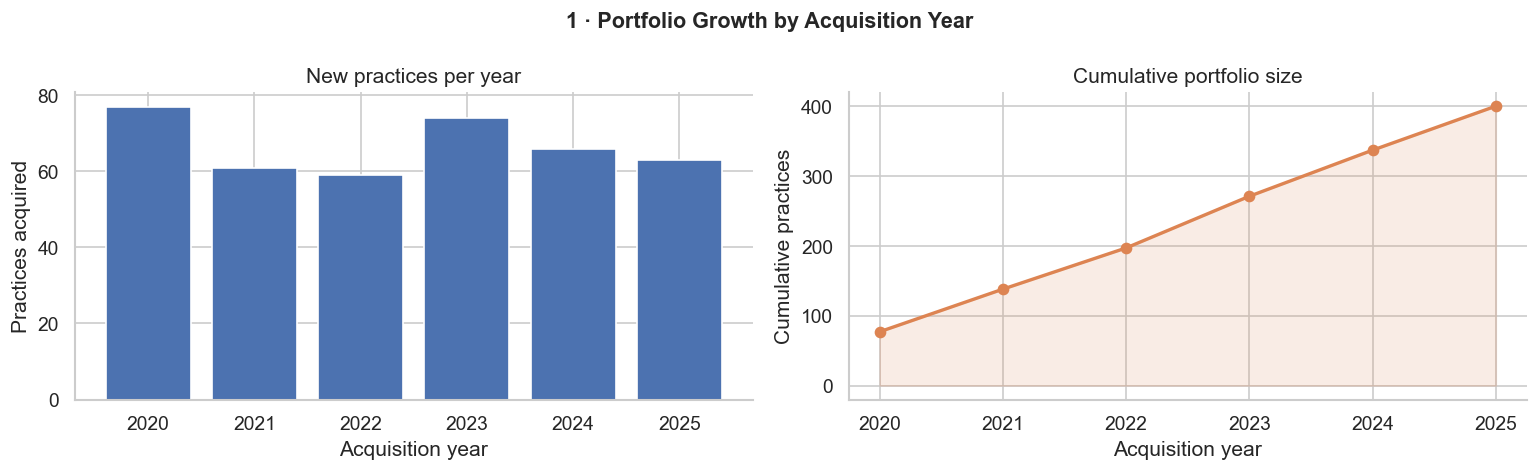

In [6]:
# ── Portfolio growth – acquisitions per year ───────────────────────────────
acq_counts = df['acquired_year'].value_counts().sort_index()
acq_cumulative = acq_counts.cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('1 · Portfolio Growth by Acquisition Year', fontsize=13, fontweight='bold')

ax1.bar(acq_counts.index, acq_counts.values, color=BLUE, edgecolor='white')
ax1.set_xlabel('Acquisition year')
ax1.set_ylabel('Practices acquired')
ax1.set_title('New practices per year')

ax2.plot(acq_cumulative.index, acq_cumulative.values, marker='o', color=ORANGE, lw=2)
ax2.fill_between(acq_cumulative.index, acq_cumulative.values, alpha=0.15, color=ORANGE)
ax2.set_xlabel('Acquisition year')
ax2.set_ylabel('Cumulative practices')
ax2.set_title('Cumulative portfolio size')

plt.tight_layout()
plt.show()

#### Interpretation — Portfolio growth

Acquisition year is a critical **maturity signal** when interpreting any individual
practice's performance metrics:

- **Practices acquired in the last 12–18 months** should not be compared to portfolio
  averages without adjustment — integration lags, patient attrition following ownership
  change and staff turnover typically depress income and productivity metrics temporarily.
- **Practices acquired 3+ years ago that remain below median on income or productivity**
  are the portfolio's chronic underperformers. These warrant a structural review: is the
  issue location, competition, management, or a fundamentally mismatched archetype
  (e.g. a practice operating as NHS Led in an area with low NHS contract availability)?
- A **step-change in annual acquisitions** (e.g. a spike in 2023–24) concentrates
  integration risk — a large cohort of recently-acquired practices depresses portfolio
  KPIs temporarily and can mask genuine performance problems in older sites.

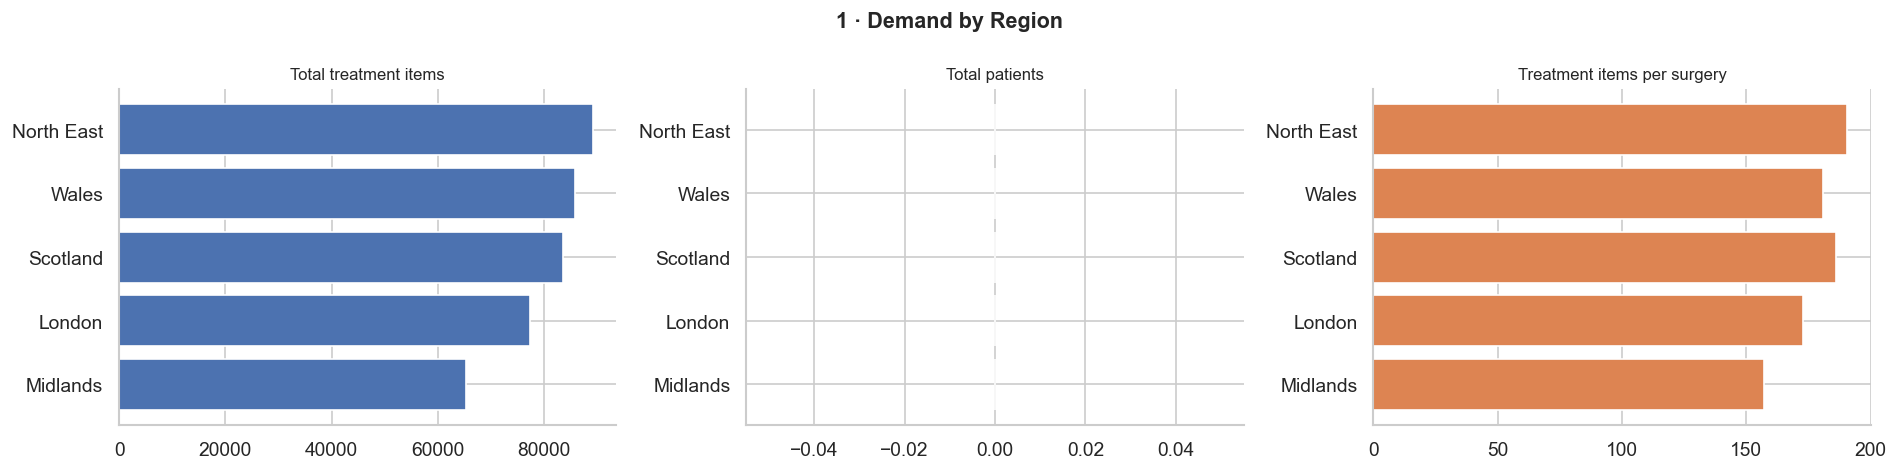

,total_treatment_items,total_patients,numberofsurgeries,items_per_surgery
region,,,,
North East,89177,0,468,190.5
Wales,85908,0,475,180.9
Scotland,83602,0,449,186.2
London,77349,0,448,172.7
Midlands,65372,0,416,157.1


In [7]:
# ── Demand by region ───────────────────────────────────────────────────────
region_demand = (
    df.groupby('region')[['total_treatment_items', 'total_patients', 'numberofsurgeries']]
    .agg({'total_treatment_items': 'sum', 'total_patients': 'sum', 'numberofsurgeries': 'sum'})
    .assign(
        items_per_surgery=lambda x: x['total_treatment_items'] / x['numberofsurgeries'].clip(lower=1)
    )
    .sort_values('total_treatment_items', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('1 · Demand by Region', fontsize=13, fontweight='bold')

for ax, col, title, color in zip(
    axes,
    ['total_treatment_items', 'total_patients', 'items_per_surgery'],
    ['Total treatment items', 'Total patients', 'Treatment items per surgery'],
    [BLUE, GREEN, ORANGE]
):
    ax.barh(region_demand.index, region_demand[col], color=color, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

region_demand.round(1)

#### Interpretation — Regional demand

The third chart — **treatment items per surgery** — is the most important for
practice-level benchmarking because it normalises for practice size.

- A region with **high total treatment items but low items per surgery** has many large
  practices that are not filling their capacity — a workforce or scheduling issue, not a
  demand issue.
- A region with **low total items but high items per surgery** has highly productive but
  small practices — physical estate may be the growth constraint.
- **Practice-level action**: if your practice's items-per-surgery is more than 20% below
  the regional average, investigate: Are all surgeries open every session? Is the
  appointment book full? What is the active patient recall conversion rate?

,practices,avg_chairs,avg_staff,avg_items,avg_private_income
size_band,,,,,
Small (1-2),44,2.5,11.8,1095.7,27944.5
Medium (3-4),93,4.0,11.9,1010.7,27197.8
Large (5-6),102,6.1,11.8,969.6,25406.4
XL (7+),161,8.4,11.9,995.7,27777.9


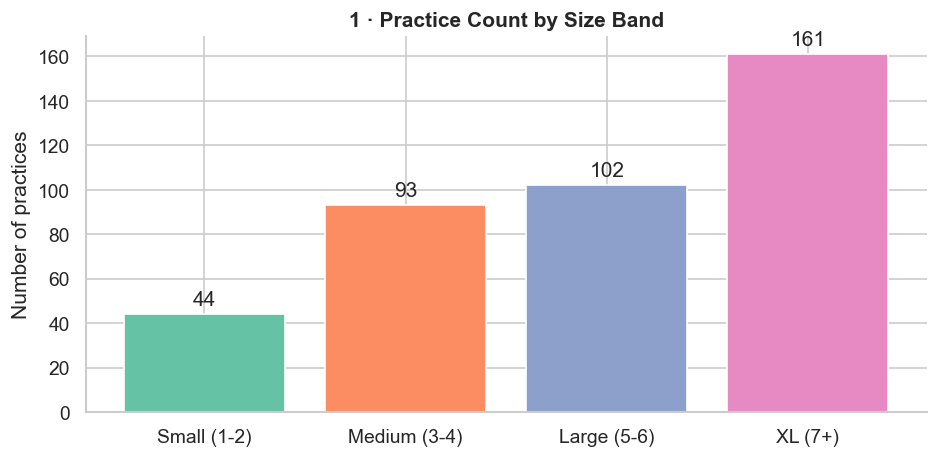

In [8]:
# ── Size segmentation ─────────────────────────────────────────────────────
df['size_band'] = pd.cut(
    df['numberofsurgeries'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['Small (1-2)', 'Medium (3-4)', 'Large (5-6)', 'XL (7+)']
)

size_band_summary = (
    df.groupby('size_band', observed=True)
    .agg(
        practices=('practicekey', 'count'),
        avg_chairs=('numberofchairs', 'mean'),
        avg_staff=('unique_staff_ids', 'mean'),
        avg_items=('total_treatment_items', 'mean'),
        avg_private_income=('privateincome', 'mean'),
    )
    .round(1)
)

display(size_band_summary)

fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette(PALETTE, len(size_band_summary))
bars = ax.bar(size_band_summary.index, size_band_summary['practices'], color=colors, edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('1 · Practice Count by Size Band', fontweight='bold')
ax.set_ylabel('Number of practices')
plt.tight_layout()
plt.show()

#### Interpretation — Size segmentation

The summary table reveals how **average private income scales with practice size**. At a
practice level, the key signal is the gap between your actual private income and the
average for your size band:

- **Private income materially below size-band average**: the practice is likely
  over-indexed on NHS activity relative to peers of the same physical scale — an
  opportunity to grow private income through case mix development, hygiene recall
  programmes or introducing specialist services.
- **Private income above size-band average**: the practice has either a strong private
  culture or a more affluent patient base — protect this through staffing choices
  (hygienists, treatment coordinators) and ensure the NHS contract doesn't crowd out
  private appointment availability.
- **Small practices with high treatment items**: watch for burnout risk — the practice
  may be operating beyond sustainable capacity with a thin staffing model.

---
## 2 · NHS vs Private Mix & Revenue

### What this section tells us

The NHS/private mix is the single most important commercial characteristic of a practice.
It determines revenue per patient, income stability (NHS contracts provide a floor,
private income is more volatile but higher margin), staffing needs and the required
skill set of the team.

**Key practice-level questions:**
- Is the practice's private income share growing, stable or declining year-on-year?
- Is private *income* share higher or lower than private *patient* share? A higher income
  share suggests the practice charges well for private work; a lower income share may
  indicate under-pricing of private treatments relative to complexity.
- Which direction is the practice *capable* of moving given its location, competition and
  current team skill set?

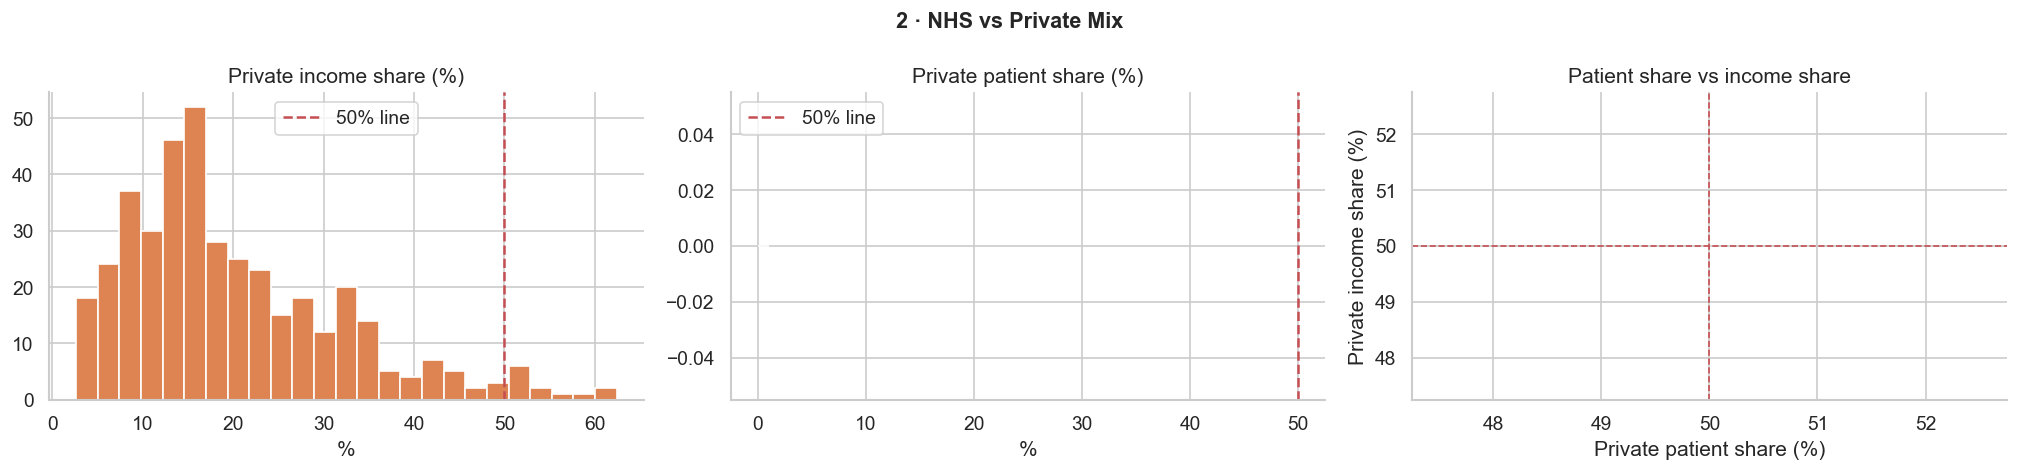

In [9]:
# ── Revenue decomposition ─────────────────────────────────────────────────

df['nhs_income_est'] = df['nhsincome'].fillna(0)
df['total_income_est'] = df['privateincome'].fillna(0) + df['nhs_income_est']
df['private_income_pct'] = np.where(
    df['total_income_est'] > 0,
    df['privateincome'].fillna(0) / df['total_income_est'] * 100,
    np.nan
)

# Patient-side mix
df['private_patients'] = df['noofpatients_private_standard'].fillna(0) + df['noofpatients_private_referral'].fillna(0)
df['nhs_patients']     = df['noofpatients_nhs_standard'].fillna(0)     + df['noofpatients_nhs_referral'].fillna(0)
df['private_patient_pct'] = np.where(
    df['total_patients'] > 0,
    df['private_patients'] / df['total_patients'] * 100,
    np.nan
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('2 · NHS vs Private Mix', fontsize=13, fontweight='bold')

axes[0].hist(df['private_income_pct'].dropna(), bins=25, color=ORANGE, edgecolor='white')
axes[0].axvline(50, color=RED, lw=1.5, ls='--', label='50% line')
axes[0].set_title('Private income share (%)')
axes[0].set_xlabel('%')
axes[0].legend()

axes[1].hist(df['private_patient_pct'].dropna(), bins=25, color=BLUE, edgecolor='white')
axes[1].axvline(50, color=RED, lw=1.5, ls='--', label='50% line')
axes[1].set_title('Private patient share (%)')
axes[1].set_xlabel('%')
axes[1].legend()

axes[2].scatter(df['private_patient_pct'], df['private_income_pct'],
                alpha=0.4, s=25, color=GREEN)
axes[2].axhline(50, color=RED, lw=1, ls='--')
axes[2].axvline(50, color=RED, lw=1, ls='--')
axes[2].set_xlabel('Private patient share (%)')
axes[2].set_ylabel('Private income share (%)')
axes[2].set_title('Patient share vs income share')

plt.tight_layout()
plt.show()

#### Interpretation — Revenue decomposition

**Private income share histogram:** A bimodal distribution (two humps) would indicate
two distinct practice populations — one NHS-dominated, one private-dominated — with few
in the middle. A single broad distribution suggests the portfolio is genuinely mixed.

**Patient share vs income share scatter (third panel):**
- Points **above the diagonal** (income share > patient share): the practice charges
  proportionally more for private patients than its volume would suggest — strong private
  pricing or case mix skewed toward high-value treatments (implants, aligners, whitening).
  This is a healthy sign of commercial maturity.
- Points **below the diagonal**: private patients are present but income per private
  patient is low — potentially under-pricing, high treatment plan abandonment, or a
  mix dominated by lower-value items like check-ups rather than restorative work.
- **Practice-level action for below-diagonal practices**: review private treatment plan
  conversion rates, average private item value, and whether the hygiene recall programme
  is actively cross-referring into restorative private work.

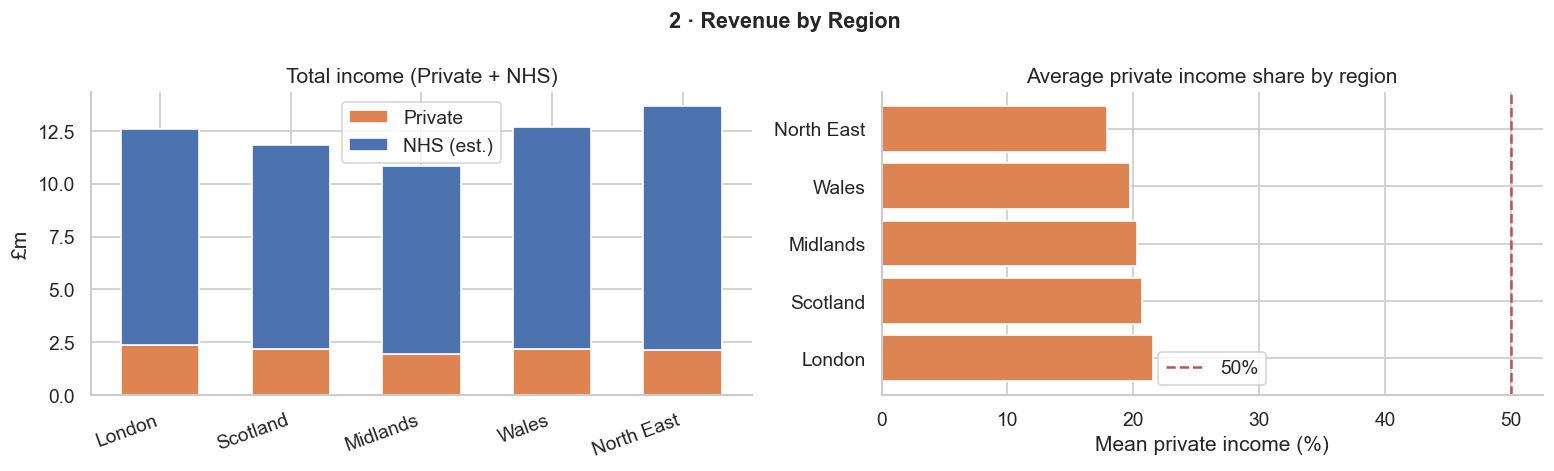

,practices,total_private_income,total_nhs_income,avg_private_pct,income_per_practice
region,,,,,
London,84,2383009.0,10187296.0,22.0,149646.0
Scotland,76,2195454.0,9639952.0,21.0,155729.0
Midlands,69,1924859.0,8890056.0,20.0,156738.0
Wales,83,2172886.0,10529260.0,20.0,153038.0
North East,88,2146443.0,11506992.0,18.0,155153.0


In [10]:
# ── Mix by region ─────────────────────────────────────────────────────────
region_mix = (
    df.groupby('region')
    .agg(
        total_private_income=('privateincome', 'sum'),
        total_nhs_income=('nhs_income_est', 'sum'),
        total_income=('total_income_est', 'sum'),
        avg_private_pct=('private_income_pct', 'mean'),
        practices=('practicekey', 'count'),
    )
    .assign(income_per_practice=lambda x: x['total_income'] / x['practices'])
    .sort_values('avg_private_pct', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('2 · Revenue by Region', fontsize=13, fontweight='bold')

# Stacked bar – absolute income split
x = np.arange(len(region_mix))
w = 0.6
axes[0].bar(x, region_mix['total_private_income'] / 1e6, width=w, color=ORANGE, label='Private', edgecolor='white')
axes[0].bar(x, region_mix['total_nhs_income'] / 1e6, width=w, bottom=region_mix['total_private_income'] / 1e6,
            color=BLUE, label='NHS', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(region_mix.index, rotation=20, ha='right')
axes[0].set_ylabel('£m')
axes[0].set_title('Total income (Private + NHS)')
axes[0].legend()

# Average private % per region
bars = axes[1].barh(region_mix.index, region_mix['avg_private_pct'], color=ORANGE, edgecolor='white')
axes[1].axvline(50, color=RED, lw=1.5, ls='--', label='50%')
axes[1].set_xlabel('Mean private income (%)')
axes[1].set_title('Average private income share by region')
axes[1].legend()

plt.tight_layout()
plt.show()

region_mix[['practices', 'total_private_income', 'total_nhs_income', 'avg_private_pct', 'income_per_practice']].round(0)

#### Interpretation — Revenue by region

**Income per practice** is the most useful single-practice benchmark from this chart.
A practice that is materially below the average for its region — controlling for size —
has a specific performance gap worth investigating.

- **Regions with high private mix**: practices here have a natural tail-wind for private
  income growth. Practices that are *still* NHS-dominated in a predominantly private
  regional portfolio are likely constrained by NHS contract obligations rather than
  market demand — review contract volume relative to competitor market.
- **Regions with low private mix**: this may reflect genuine demographic and competitive
  constraints. Pressure on individual practices to raise private income without regional
  context risks patient dissatisfaction and recall list attrition.
- Watch for practices in high-private-mix regions whose own private % is well below
  the regional average — these are the clearest commercial development opportunities.

In [ ]:
# ── Practice-level mix segmentation ──────────────────────────────────────
bins_pct = [0, 20, 50, 80, 100]
labels_pct = ['NHS-led (<20% private)', 'Mixed-NHS (20-50%)', 'Mixed-Private (50-80%)', 'Private-led (>80%)']
df['income_mix_segment'] = pd.cut(df['private_income_pct'], bins=bins_pct, labels=labels_pct, include_lowest=True)

seg_counts = df['income_mix_segment'].value_counts().reindex(labels_pct)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [BLUE, '#74a9cf', ORANGE, RED]
bars = ax.bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
ax.bar_label(bars, padding=3)
ax.set_title('2 · Practice Count by Income Mix Segment', fontweight='bold')
ax.set_ylabel('Number of practices')
ax.set_xticklabels(seg_counts.index, rotation=15, ha='right')
plt.tight_layout()
plt.show()

#### Interpretation — Income mix segments

This segmentation is the practical classification layer for commercial planning:

- **NHS-led (<20% private)**: income is stable and contractually guaranteed but
  growth-capped. The priority question is whether the NHS contract is being *fully
  delivered* — under-delivery wastes contracted income and risks clawback.
- **Mixed-NHS (20–50% private)**: the practice has begun the private journey but has
  significant headroom. Focus: grow private recall, introduce hygiene services, develop
  treatment coordinator capability.
- **Mixed-Private (50–80%)**: commercially mature. Focus shifts to *protecting* private
  income quality — case mix, pricing, experience — and ensuring NHS obligations are met
  efficiently without crowding the appointment book.
- **Private-led (>80%)**: maximum private exposure means higher revenue per patient
  but also higher sensitivity to economic shocks. Ensure active patient recall is robust
  and that the practice is not overly dependent on a small number of high-value patients.

---
## 3 · Standard vs Specialist Referral Intensity

### What this section tells us

Referral intensity captures whether a practice is operating as a **standard generalist**
or beginning to develop a **specialist/hub** identity. Practices that refer *out* are
losing revenue — every referral to an external specialist is income the practice could
potentially retain. Practices that receive referrals *in* (via SNARE or informal networks)
have established a reputational specialist position.

**Key practice-level questions:**
- What proportion of the practice's treatment items require specialist referral, and is
  that proportion growing?
- Are referrals being *tracked*? A practice with high treatment volume but zero SNARE
  activity may be losing specialist cases informally without capturing the data.
- Is there a dentist in the practice with a special interest who could retain cases
  currently being referred out (e.g. implants, endodontics, orthodontics)?

In [ ]:
# ── Referral rate calculations ────────────────────────────────────────────
df['private_referral_items'] = df['nooftreatmentitems_private_referral'].fillna(0)
df['nhs_referral_items']     = df['nooftreatmentitems_nhs_referral'].fillna(0)
df['total_referral_items']   = df['private_referral_items'] + df['nhs_referral_items']

df['private_standard_items'] = df['nooftreatmentitems_private_standard'].fillna(0)
df['nhs_standard_items']     = df['nooftreatmentitems_nhs_standard'].fillna(0)
df['total_standard_items']   = df['private_standard_items'] + df['nhs_standard_items']

df['total_items_all'] = df['total_referral_items'] + df['total_standard_items']

df['referral_rate_pct'] = np.where(
    df['total_items_all'] > 0,
    df['total_referral_items'] / df['total_items_all'] * 100,
    np.nan
)

# Referral patients
df['private_referral_patients'] = df['noofpatients_private_referral'].fillna(0)
df['nhs_referral_patients']     = df['noofpatients_nhs_referral'].fillna(0)
df['total_referral_patients']   = df['private_referral_patients'] + df['nhs_referral_patients']

df['referral_patient_rate_pct'] = np.where(
    df['total_patients'] > 0,
    df['total_referral_patients'] / df['total_patients'] * 100,
    np.nan
)

print('Referral intensity summary:')
print(df[['referral_rate_pct', 'referral_patient_rate_pct', 'total_referral_items', 'countof_snareid']].describe().round(2))

#### Interpretation — Referral rates

With real data, watch for:
- **Referral rate above 15%** of treatment items: the practice is consistently sending a
  material proportion of its patient base to external providers — review whether an
  in-house specialist appointment session could capture that revenue.
- **Zero referral rate with high treatment volume**: either the practice is retaining all
  complexity in-house (positive, if clinical governance is robust) or it is not correctly
  coding referral items (a data quality issue to investigate).
- **High private referral + low NHS referral**: the practice is managing NHS cases
  in-house but out-referring private complexity — the opposite of the commercial optimum.

In [ ]:
# ── Referral distribution and profile plots ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('3 · Referral Intensity', fontsize=13, fontweight='bold')

# Distribution of referral rates
axes[0].hist(df['referral_rate_pct'].dropna(), bins=30, color=GREEN, edgecolor='white')
axes[0].axvline(df['referral_rate_pct'].median(), color=RED, lw=1.8, ls='--',
                label=f"Median {df['referral_rate_pct'].median():.1f}%")
axes[0].set_title('Referral rate (% of treatment items)')
axes[0].set_xlabel('%')
axes[0].legend(fontsize=8)

# NHS vs Private referral split
ref_totals = pd.Series({
    'Private referral': df['private_referral_items'].sum(),
    'NHS referral': df['nhs_referral_items'].sum(),
    'Private standard': df['private_standard_items'].sum(),
    'NHS standard': df['nhs_standard_items'].sum(),
})
colors_pie = [ORANGE, BLUE, '#f4a460', '#7bafd4']
axes[1].pie(ref_totals, labels=ref_totals.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Treatment items by type')

# Referral rate by region
region_ref = (
    df.groupby('region')['referral_rate_pct']
    .agg(['mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)
axes[2].barh(region_ref.index, region_ref['mean'], xerr=region_ref['std'],
             color=GREEN, edgecolor='white', capsize=4, alpha=0.8)
axes[2].set_title('Referral rate by region (mean ± SD)')
axes[2].set_xlabel('Referral rate (%)')

plt.tight_layout()
plt.show()

#### Interpretation — Referral distribution and regional variation

**Referral rate distribution**: If the histogram is right-skewed with a long tail, a
small number of practices are driving the majority of specialist activity. These are
your natural Specialist/Referral Hub candidates.

**Regional variation (third panel)**: A region with consistently higher referral rates
may reflect a demographic profile (older patients, more complex disease burden) or a
supply-side gap (fewer specialist practices nearby, more general practices referring out).
Both require different responses:
- *Demographic driver*: invest in in-house specialist capacity at existing practices.
- *Supply gap driver*: consider whether a dedicated hub practice in that region could
  receive referrals from the broader practice network.

In [ ]:
# ── SNARE / specialist activity ───────────────────────────────────────────
# countof_snareid = specialist network activity count
df['has_specialist_activity'] = df['countof_snareid'] > 0

print(f"Practices with specialist (SNARE) activity: "
      f"{df['has_specialist_activity'].sum()} ({df['has_specialist_activity'].mean()*100:.1f}%)")

# Top-decile referrers vs rest
ref_threshold = df['referral_rate_pct'].quantile(0.9)
df['high_referrer'] = df['referral_rate_pct'] > ref_threshold

compare = (
    df.groupby('high_referrer')
    .agg(
        n=('practicekey', 'count'),
        avg_private_income=('privateincome', 'mean'),
        avg_total_income=('total_income_est', 'mean'),
        avg_referral_rate=('referral_rate_pct', 'mean'),
        avg_nps=('nps', 'mean'),
    )
    .round(1)
)
compare.index = ['Standard referrers', f'High referrers (>{ref_threshold:.1f}%)']
display(compare)

#### Interpretation — Specialist activity and high-referrer comparison

The **high-referrer vs standard comparison table** is a useful practice-level benchmarking
tool. The key column to watch is `avg_total_income`:

- If high-referrers generate **lower** total income than standard practices: specialist
  activity is being referred *out* (income-losing) rather than received *in*. The practice
  is generating referrals for others to monetise.
- If high-referrers generate **higher** total income: the practice has developed a
  specialist reputation and is attracting referral patients — a hub model is emerging
  organically and should be supported with appropriate staffing (specialist dentists,
  dedicated treatment coordinator, extended appointment slots).

---
## 4 · Workforce Mix & Role Design

### What this section tells us

Workforce mix is simultaneously a **capacity constraint** and a **commercial lever**.
The right staffing model for a practice depends on its archetype — an NHS Led practice
needs dentist clinical hours optimised for throughput; a Specialist/Referral Hub needs
a different skill mix and higher nurse specialisation.

**Key practice-level questions:**
- Is the practice's nurse:dentist ratio above 1:1? Below 1:1 means dentists are either
  working without dedicated chair-side support (clinical risk) or nurses are covering
  multiple surgeries simultaneously (productivity drag).
- Does the practice have a hygienist? If not, and private income share is above 30%, this
  is the highest-return single hire the practice could make.
- Are contracted clinical hours aligned with the appointment book? A practice with high
  dentist hours but low treatment items may have scheduling or demand-generation problems
  rather than a capacity problem.

In [ ]:
# ── Workforce composition ─────────────────────────────────────────────────
role_cols  = ['position_dentist', 'position_dental_nurse',
              'position_receptionist', 'position_hygienist', 'position_practice_manager']
hours_cols = ['contractualhours_dentist', 'contractualhours_dental_nurse',
              'contractualhours_receptionist', 'contractualhours_hygienist',
              'contractualhours_practice_manager']
role_labels = ['Dentist', 'Dental Nurse', 'Receptionist', 'Hygienist', 'Practice Mgr']

df['total_clinical_roles'] = df[['position_dentist', 'position_dental_nurse', 'position_hygienist']].sum(axis=1)
df['support_roles']        = df[['position_receptionist', 'position_practice_manager']].sum(axis=1)
df['total_contractual_hours'] = df[hours_cols].sum(axis=1)
df['clinical_hours'] = df[['contractualhours_dentist', 'contractualhours_dental_nurse',
                            'contractualhours_hygienist']].sum(axis=1)
df['nurse_to_dentist_ratio'] = (
    df['position_dental_nurse'] / df['position_dentist'].replace(0, np.nan)
)
df['hygienist_flag'] = df['position_hygienist'] > 0

# Total headcounts
totals_by_role = pd.Series({label: df[col].sum() for col, label in zip(role_cols, role_labels)})

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('4 · Workforce Mix', fontsize=13, fontweight='bold')

# Portfolio headcount
colors_roles = sns.color_palette(PALETTE, len(role_labels))
axes[0].bar(role_labels, totals_by_role.values, color=colors_roles, edgecolor='white')
axes[0].set_title('Total headcount by role (portfolio)')
axes[0].set_ylabel('Headcount')

# Nurse:Dentist ratio distribution
axes[1].hist(df['nurse_to_dentist_ratio'].dropna(), bins=15, color=BLUE, edgecolor='white')
axes[1].axvline(df['nurse_to_dentist_ratio'].median(), color=RED, lw=1.8, ls='--',
                label=f"Median {df['nurse_to_dentist_ratio'].median():.2f}")
axes[1].set_title('Nurse:Dentist ratio')
axes[1].set_xlabel('Nurses per dentist')
axes[1].legend()

# Hygienist penetration
hyg_pct = df['hygienist_flag'].mean() * 100
axes[2].pie(
    [hyg_pct, 100 - hyg_pct],
    labels=[f'Has hygienist\n{hyg_pct:.1f}%', f'No hygienist\n{100-hyg_pct:.1f}%'],
    colors=[GREEN, GREY], startangle=90,
    textprops={'fontsize': 10}, autopct=None
)
axes[2].set_title('Hygienist penetration')

plt.tight_layout()
plt.show()

#### Interpretation — Workforce composition

**Portfolio headcount chart**: Dental nurses are typically the largest role group.
If nurses are proportionally fewer than dentists in the portfolio, clinical governance
risk increases (1:1 chair-side coverage is the standard).

**Nurse:Dentist ratio distribution**:
- **Ratio < 1.0**: some dentists are without dedicated chair-side support. Identify these
  practices — they carry clinical risk and likely have lower throughput.
- **Ratio > 1.5**: nurses may be cross-covering multiple surgeries, or the practice has
  nurses in non-clinical roles (treatment coordination, decontamination). Neither is
  necessarily a problem but warrants review.
- **Practices at the median ratio**: well-calibrated chair-side model. Focus on hours
  alignment rather than headcount.

**Hygienist penetration**: The practices *without* a hygienist are the highest-priority
targets for private income development — a hygienist brings in recurring recall revenue
and is the primary conduit for converting NHS patients to private whitening and
cosmetic consultations.

In [ ]:
# ── Workforce vs size and income ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('4 · Workforce Relationships', fontsize=13, fontweight='bold')

axes[0].scatter(df['position_dentist'], df['numberofsurgeries'],
                alpha=0.35, s=25, color=BLUE)
axes[0].set_xlabel('No. of dentists')
axes[0].set_ylabel('No. of surgeries')
axes[0].set_title('Dentists vs surgeries')

axes[1].scatter(df['position_dentist'], df['privateincome'],
                alpha=0.35, s=25, color=ORANGE)
axes[1].set_xlabel('No. of dentists')
axes[1].set_ylabel('Private income (£)')
axes[1].set_title('Dentists vs private income')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

axes[2].scatter(df['position_hygienist'], df['private_income_pct'],
                alpha=0.35, s=25, color=GREEN)
axes[2].set_xlabel('No. of hygienists')
axes[2].set_ylabel('Private income share (%)')
axes[2].set_title('Hygienists vs private income share')

plt.tight_layout()
plt.show()

#### Interpretation — Workforce relationships

**Dentists vs surgeries scatter**: Points clustered along the diagonal indicate a
well-matched model (roughly one dentist per surgery). Points *above* the diagonal
(more surgeries than dentists) indicate under-staffed surgeries — chairs sitting empty.
Points *below* (more dentists than surgeries) suggest session-sharing or part-time
arrangements — the surgeries are the bottleneck.

**Dentists vs private income scatter**: Look for outliers:
- High dentists, *low* private income: more bodies than revenue — either the dentists
  are predominantly doing NHS work, are working reduced sessions, or the practice is
  not converting capacity to private income.
- Low dentists, *high* private income: a lean, high-performing private model — potentially
  a high-value associate arrangement. Retention risk if the practice is dependent on
  one or two high-billing individuals.

**Hygienists vs private income share**: A rising relationship here confirms that
hygienist presence is a genuine leading indicator of private mix maturity.

In [ ]:
# ── Role ratios by size band ───────────────────────────────────────────────
role_by_size = (
    df.groupby('size_band', observed=True)
    .agg(
        avg_dentists=('position_dentist', 'mean'),
        avg_nurses=('position_dental_nurse', 'mean'),
        avg_hygienists=('position_hygienist', 'mean'),
        avg_receptionists=('position_receptionist', 'mean'),
        avg_nurse_dentist_ratio=('nurse_to_dentist_ratio', 'mean'),
        pct_with_hygienist=('hygienist_flag', 'mean'),
    )
    .round(2)
)
role_by_size['pct_with_hygienist'] = (role_by_size['pct_with_hygienist'] * 100).round(1)

display(role_by_size)

#### Interpretation — Role ratios by size band

This table is a **workforce planning benchmark**. For any given practice, compare its
role ratios to the average for its size band:

- **Nurses below size-band average**: understaffed for clinical throughput — either
  accept lower dentist utilisation or recruit. Calculate the cost of a dental nurse
  FTE against the revenue unlocked by increasing dentist sessions.
- **Hygienists below size-band average**: the single highest-return gap for private
  income growth in Medium and Large practices.
- **Nurse:Dentist ratio below size-band average**: a structural staffing imbalance —
  escalating this to HR with specific headcount targets is more effective than a
  general 'recruit nurses' instruction.
- **Practice Manager absent (proportion = 0)**: in Small practices this may be the
  right model (dentist-owner manages the practice). In Medium and above, absence of
  a dedicated PM typically correlates with operational inefficiency and compliance risk.

---
## 5 · Capacity & Productivity (Whitespace)

### What this section tells us

Capacity and productivity analysis answers the question: **given the physical estate and
workforce this practice has, is it generating the income it should be?**

"Whitespace" is the term for the gap between a practice's actual productivity and what
a median-performing peer with the same resources achieves. It is not a criticism —
whitespace has causes (opening hours, appointment mix, demand generation, scheduling)
and most causes have solutions.

**Key practice-level questions:**
- How many treatment items does the practice generate per surgery per week?
  Is this above or below the portfolio median?
- Is income per surgery consistent with the archetype? A Flagship practice generating
  per-surgery income at the Small/Foundation level has a significant commercial problem.
- Which productivity metric is the binding constraint — items per surgery (scheduling/
  demand) or income per item (pricing/case mix)?

In [ ]:
# ── Capacity utilisation proxies ───────────────────────────────────────────
# Treatment items per surgery (chair utilisation proxy)
df['items_per_surgery'] = df['total_treatment_items'] / df['numberofsurgeries'].replace(0, np.nan)

# Items per dentist (dentist productivity proxy)
df['items_per_dentist'] = df['total_treatment_items'] / df['position_dentist'].replace(0, np.nan)

# Income per surgery (revenue productivity)
df['income_per_surgery'] = df['total_income_est'] / df['numberofsurgeries'].replace(0, np.nan)

# Income per dentist clinical hour
df['income_per_dentist_hour'] = (
    df['total_income_est'] / df['contractualhours_dentist'].replace(0, np.nan)
)

df['nhs_income_per_dentist'] = df['nhsincome'] / df['position_dentist'].replace(0, np.nan)

productivity_cols = ['items_per_surgery', 'items_per_dentist', 'income_per_surgery',
                     'income_per_dentist_hour', 'nhs_income_per_dentist']

print('Productivity metrics summary:')
print(df[productivity_cols].describe().round(1).to_string())

#### Interpretation — Productivity metrics

Five metrics are computed. At a **practice level**, the most actionable ones are:

| Metric | What low means | Primary lever |
|--------|----------------|---------------|
| `items_per_surgery` | Surgeries underutilised | Scheduling, recall, opening hours |
| `items_per_dentist` | Dentists underutilised | Sessions, appointment mix, demand |
| `income_per_surgery` | Revenue per chair is low | Case mix, pricing, private conversion |
| `income_per_dentist_hour` | Revenue per clinical hour is low | NHS vs private balance, fee review |
| `nhs_income_per_dentist` | NHS income per dentist is low | Contract volume review, associate hours |

A practice that is **below median on `income_per_surgery` but above median on
`items_per_surgery`** is seeing high volume but low revenue per item — a pricing or
case mix issue rather than a demand or scheduling issue.

In [ ]:
# ── Whitespace – practices below median productivity ──────────────────────
PRODUCTIVITY_METRIC = 'items_per_surgery'  # change to explore others

median_prod = df[PRODUCTIVITY_METRIC].median()
p25_prod    = df[PRODUCTIVITY_METRIC].quantile(0.25)
p75_prod    = df[PRODUCTIVITY_METRIC].quantile(0.75)

df['productivity_band'] = pd.cut(
    df[PRODUCTIVITY_METRIC],
    bins=[0, p25_prod, median_prod, p75_prod, np.inf],
    labels=['Q1 – Low', 'Q2', 'Q3', 'Q4 – High'],
    include_lowest=True
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('5 · Capacity & Productivity', fontsize=13, fontweight='bold')

# Distribution
axes[0].hist(df[PRODUCTIVITY_METRIC].dropna(), bins=30, color=BLUE, edgecolor='white')
axes[0].axvline(median_prod, color=RED, lw=1.8, ls='--', label=f'Median {median_prod:.0f}')
axes[0].axvline(p25_prod, color=ORANGE, lw=1.2, ls=':', label=f'P25 {p25_prod:.0f}')
axes[0].axvline(p75_prod, color=GREEN, lw=1.2, ls=':', label=f'P75 {p75_prod:.0f}')
axes[0].set_title('Treatment items per surgery')
axes[0].legend(fontsize=8)

# Income per surgery
axes[1].hist(df['income_per_surgery'].dropna(), bins=30, color=ORANGE, edgecolor='white')
axes[1].axvline(df['income_per_surgery'].median(), color=RED, lw=1.8, ls='--',
                label=f"Median £{df['income_per_surgery'].median():,.0f}")
axes[1].set_title('Income per surgery (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[1].legend(fontsize=8)

# UDAs per dentist
axes[2].hist(df['nhs_income_per_dentist'].dropna(), bins=30, color=GREEN, edgecolor='white')
axes[2].axvline(df['nhs_income_per_dentist'].median(), color=RED, lw=1.8, ls='--',
                label=f"Median {df['nhs_income_per_dentist'].median():.0f}")
axes[2].set_title('NHS income per dentist (£)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Interpretation — Productivity bands

**Q1 (Low)** practices are generating fewer treatment items per surgery than 75% of the
portfolio. At a practice level this warrants an appointment book audit:
- What percentage of available appointment slots are filled?
- What is the average gap between booking and appointment date?
- Are late cancellations and DNAs being back-filled?
- Is the practice open on all available days/sessions?

**Q4 (High)** practices are at risk of a different problem: **over-trading**. Check:
- Are waiting times growing? A long waiting list suppresses demand-side data — patients
  stop trying to book.
- Is the team working unsustainable session patterns that will lead to turnover?
- Are clinical governance standards being maintained under pressure?

In [ ]:
# ── Whitespace opportunity sizing ─────────────────────────────────────────
# How much additional income if Q1/Q2 practices reached median productivity?

low_prod = df[df['productivity_band'].isin(['Q1 – Low', 'Q2'])].copy()

low_prod['gap_to_median_items'] = (median_prod - low_prod[PRODUCTIVITY_METRIC]) * low_prod['numberofsurgeries']
avg_income_per_item = df['total_income_est'].sum() / df['total_treatment_items'].replace(0, np.nan).sum()
low_prod['income_gap_est'] = low_prod['gap_to_median_items'] * avg_income_per_item

total_whitespace = low_prod['income_gap_est'].sum()
n_below_median   = len(low_prod)

print(f"Practices below median productivity: {n_below_median} ({n_below_median/len(df)*100:.1f}%)")
print(f"Estimated whitespace income potential: £{total_whitespace:,.0f}")
print(f"Average uplift per practice: £{total_whitespace/n_below_median:,.0f}")

# Breakdown by productivity quartile and region
whitespace_by_region = (
    low_prod.groupby('region')['income_gap_est']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'total_gap_£', 'mean': 'avg_gap_per_practice_£', 'count': 'practices'})
    .sort_values('total_gap_£', ascending=False)
    .round(0)
)
display(whitespace_by_region)

#### Interpretation — Whitespace opportunity

The **estimated whitespace income** is a theoretical ceiling, not a guaranteed uplift.
It assumes every below-median practice could reach exactly the median — which requires
both demand-side (patients exist, want appointments) and supply-side (staff, opening
hours, scheduling) conditions to be met.

**Practice-level prioritisation:**
1. Identify the **highest income-gap practices in your region** from the table above.
2. For each, determine whether the gap is driven by **low items per surgery** (scheduling
   problem — quicker to fix) or **low income per item** (case mix problem — requires
   commercial development investment).
3. Focus first on practices where the issue is scheduling and opening hours — these
   have the fastest payback with the lowest investment.
4. Save case-mix and commercial development interventions for practices where scheduling
   is already optimised but revenue per item lags.

In [ ]:
# ── Productivity quadrant: chair utilisation vs income yield ──────────────
df['norm_items_per_surgery'] = (df['items_per_surgery'] - df['items_per_surgery'].mean()) / df['items_per_surgery'].std()
df['norm_income_per_surgery'] = (df['income_per_surgery'] - df['income_per_surgery'].mean()) / df['income_per_surgery'].std()

df['quadrant'] = 'Unknown'
df.loc[(df['norm_items_per_surgery'] >= 0) & (df['norm_income_per_surgery'] >= 0), 'quadrant'] = 'High volume & High yield'
df.loc[(df['norm_items_per_surgery'] < 0)  & (df['norm_income_per_surgery'] >= 0), 'quadrant'] = 'Low volume & High yield'
df.loc[(df['norm_items_per_surgery'] >= 0) & (df['norm_income_per_surgery'] < 0),  'quadrant'] = 'High volume & Low yield'
df.loc[(df['norm_items_per_surgery'] < 0)  & (df['norm_income_per_surgery'] < 0),  'quadrant'] = 'Low volume & Low yield'

quad_palette = {
    'High volume & High yield': GREEN,
    'Low volume & High yield':  ORANGE,
    'High volume & Low yield':  BLUE,
    'Low volume & Low yield':   RED,
}

fig, ax = plt.subplots(figsize=(9, 6))

for quad, color in quad_palette.items():
    sub = df[df['quadrant'] == quad]
    ax.scatter(sub['norm_items_per_surgery'], sub['norm_income_per_surgery'],
               label=f'{quad} (n={len(sub)})', alpha=0.5, s=35, color=color)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Chair utilisation (z-score of items per surgery)')
ax.set_ylabel('Income yield (z-score of income per surgery)')
ax.set_title('5 · Productivity Quadrant – Chair Utilisation vs Income Yield', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print(df['quadrant'].value_counts().to_string())

#### Interpretation — Productivity quadrant

Each quadrant tells a different practice story:

| Quadrant | Interpretation | Priority action |
|----------|----------------|-----------------|
| **High volume & High yield** | Star performers — strong scheduling AND strong revenue per item | Protect, learn from, retain staff |
| **Low volume & High yield** | Pricing is strong but the chair isn't full enough | Demand generation, recall activation, opening hours review |
| **High volume & Low yield** | Busy but under-earning — often NHS-heavy with low private conversion | Case mix review, private conversion programme, fee audit |
| **Low volume & Low yield** | Underperforming on both dimensions | Operational deep-dive required — may need management intervention |

**The most actionable group is 'High volume & Low yield'**: these practices already
have patients in the chair — they just need a commercial development programme to shift
the case mix toward higher-value treatments.

In [ ]:
# ── Productivity by size band ─────────────────────────────────────────────
prod_by_size = (
    df.groupby('size_band', observed=True)
    .agg(
        avg_items_per_surgery=('items_per_surgery', 'mean'),
        avg_items_per_dentist=('items_per_dentist', 'mean'),
        avg_income_per_surgery=('income_per_surgery', 'mean'),
        avg_nhs_income_per_dentist=('nhs_income_per_dentist', 'mean'),
        n=('practicekey', 'count'),
    )
    .round(1)
)
display(prod_by_size)

#### Interpretation — Productivity by size band

**Expected pattern**: income per surgery should be broadly similar across size bands
(more surgeries = more income, but not more income per surgery). If large practices
show materially *lower* income per surgery than small ones, the estate is not being
used proportionally — the physical growth has outrun commercial development.

**Red flags in this table:**
- `avg_income_per_surgery` declining as size increases: larger practices are under-
  utilising the additional capacity they have acquired.
- `avg_nhs_income_per_dentist` declining as size increases: NHS contract delivery is becoming
  less efficient at scale — possible associate hours misalignment or treatment coding issues.
- `avg_items_per_surgery` stable across sizes: healthy — all sizes are running a
  consistent volume per chair. The income lever is then about *what* is in those items.

---
## Summary Dashboard

In [ ]:
# ── Top-level KPI snapshot ────────────────────────────────────────────────
kpis = {
    'Total practices': len(df),
    'Active practices': (df['status'] == 'Active').sum(),
    'Avg surgeries': df['numberofsurgeries'].mean(),
    'Avg staff headcount': df['unique_staff_ids'].mean(),
    'Total portfolio income (£m)': df['total_income_est'].sum() / 1e6,
    'Avg private income share (%)': df['private_income_pct'].mean(),
    'Avg referral rate (%)': df['referral_rate_pct'].mean(),
    'Pct practices with hygienist': df['hygienist_flag'].mean() * 100,
    'Avg items per surgery': df['items_per_surgery'].mean(),
    'Estimated whitespace (£m)': total_whitespace / 1e6,
}

kpi_df = pd.DataFrame.from_dict(kpis, orient='index', columns=['Value'])
kpi_df['Value'] = kpi_df['Value'].round(2)
display(kpi_df)